# Verification of the Shahrezaei-Swain three-stage gene-expression model

This notebook verifies the curated model at two levels. First, it reruns BioNetGen
and compares the seeded stationary protein distribution with an independently
assembled finite-state chemical master equation (CME). Second, it compares the
curated BioNetGen distribution with the red $\gamma=10$ simulation curve reported
in Fig. 3D of Shahrezaei and Swain (2008), and evaluates the paper's analytical
large-$\gamma$ distribution (Eq. 18).

In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import tempfile

import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
from scipy.special import gammaln, hyp2f1

MODEL_ID = "three_stage_stochastic_gene_expression_shahrezaei2008"
PRIMARY = f"{MODEL_ID}.bngl"
MODEL_DIR = Path.cwd()
REFERENCE_DIR = MODEL_DIR / "reference"
BURN_IN = 10_000_000.0

assert (MODEL_DIR / PRIMARY).is_file()
assert REFERENCE_DIR.is_dir()

## 1. Fresh BioNetGen execution

The canonical BNGL file is copied to a temporary directory and executed there, so
the test cannot accidentally reuse committed output. The active direct-SSA action
runs for 210 million seconds with a fixed seed. Samples through 10 million seconds
are burn-in; the remaining 10,000 uniformly spaced samples estimate the stationary
distribution. The fresh files are compared exactly with the committed references.

In [2]:
def find_bng2():
    candidates = [
        os.environ.get("BNG2_PL"),
        str(Path.home() / "Simulations" / "BioNetGen-2.9.3" / "BNG2.pl"),
    ]
    for candidate in candidates:
        if candidate and Path(candidate).is_file():
            return Path(candidate)
    raise FileNotFoundError(
        "Set BNG2_PL to the BioNetGen BNG2.pl executable before running this notebook."
    )


bng2 = find_bng2()
with tempfile.TemporaryDirectory(prefix="shahrezaei2008_bng_") as tmp:
    run_dir = Path(tmp)
    run_model = run_dir / PRIMARY
    shutil.copy2(MODEL_DIR / PRIMARY, run_model)
    result = subprocess.run(
        ["perl", str(bng2), "--outdir", str(run_dir), str(run_model)],
        check=True,
        capture_output=True,
        text=True,
        timeout=120,
    )
    fresh_ssa = np.loadtxt(run_dir / f"{MODEL_ID}_ssa.gdat")
    fresh_cdat = np.loadtxt(run_dir / f"{MODEL_ID}_ssa.cdat")
    fresh_net = (run_dir / f"{MODEL_ID}.net").read_text()
    fresh_ssa_net = (run_dir / f"{MODEL_ID}_ssa.net").read_text()

reference_ssa = np.loadtxt(REFERENCE_DIR / f"{MODEL_ID}_ssa.gdat")
reference_cdat = np.loadtxt(REFERENCE_DIR / f"{MODEL_ID}_ssa.cdat")
reference_net = (REFERENCE_DIR / f"{MODEL_ID}.net").read_text()
reference_ssa_net = (REFERENCE_DIR / f"{MODEL_ID}_ssa.net").read_text()

np.testing.assert_allclose(fresh_ssa, reference_ssa, rtol=0.0, atol=0.0)
np.testing.assert_allclose(fresh_cdat, reference_cdat, rtol=0.0, atol=0.0)
assert fresh_net == reference_net
assert fresh_ssa_net == reference_ssa_net

print(f"BioNetGen: {result.stdout.splitlines()[0]}")
print(f"Fresh samples: {len(fresh_ssa):,}")
print("Fresh seeded outputs exactly match all committed reference outputs.")

BioNetGen: BioNetGen version 2.9.3
Fresh samples: 10,501
Fresh seeded outputs exactly match all committed reference outputs.


## 2. Independent finite-state chemical master equation

For promoter state $s\in\{0,1\}$, transcript count $m$, and protein count $n$,
the independent generator contains these channels:

\[
0 \xrightarrow{k_0} 1,\quad 1 \xrightarrow{k_1} 0,\quad
m \xrightarrow{v_0 s} m+1,\quad m \xrightarrow{d_0m} m-1,
\]
\[
n \xrightarrow{v_1m} n+1,\quad n \xrightarrow{d_1n} n-1.
\]

This is assembled directly from the paper's master equation, not from the generated
BioNetGen network. The stationary solution of $Q^T p=0$ is computed on
$m=0\ldots12$ and $n=0\ldots220$. Boundary probabilities and the stationarity
residual verify that the truncation is negligible.

In [3]:
def stationary_cme(m_max=12, n_max=220):
    k0, k1 = 0.6 * 0.0005, 0.2 * 0.0005
    v0, v1 = 4.0 * 0.0005, 10.0 * (10.0 * 0.0005)
    d0, d1 = 10.0 * 0.0005, 0.0005
    n_states = 2 * (m_max + 1) * (n_max + 1)

    def index(s, m, n):
        return (s * (m_max + 1) + m) * (n_max + 1) + n

    rows, cols, values = [], [], []
    for s in range(2):
        for m in range(m_max + 1):
            for n in range(n_max + 1):
                source = index(s, m, n)
                total = [0.0]

                def add(target_s, target_m, target_n, rate):
                    if 0 <= target_m <= m_max and 0 <= target_n <= n_max:
                        rows.append(source)
                        cols.append(index(target_s, target_m, target_n))
                        values.append(rate)
                        total[0] += rate

                add(1 - s, m, n, k0 if s == 0 else k1)
                if s == 1:
                    add(s, m + 1, n, v0)
                if m:
                    add(s, m - 1, n, d0 * m)
                    add(s, m, n + 1, v1 * m)
                if n:
                    add(s, m, n - 1, d1 * n)
                rows.append(source)
                cols.append(source)
                values.append(-total[0])

    generator = coo_matrix(
        (values, (rows, cols)), shape=(n_states, n_states)
    ).tocsr()
    system = generator.T.tolil()
    rhs = np.zeros(n_states)
    system[-1, :] = 1.0
    rhs[-1] = 1.0
    stationary = spsolve(system.tocsr(), rhs)

    protein = np.zeros(n_max + 1)
    for s in range(2):
        for m in range(m_max + 1):
            start = index(s, m, 0)
            protein += stationary[start : start + n_max + 1]

    m_boundary = sum(
        stationary[index(s, m_max, 0) : index(s, m_max, n_max) + 1].sum()
        for s in range(2)
    )
    residual = np.max(np.abs(generator.T @ stationary))
    return protein, m_boundary, protein[-1], residual


protein_cme, m_boundary, protein_boundary, cme_residual = stationary_cme()
assert m_boundary < 1e-10
assert protein_boundary < 1e-6
assert cme_residual < 1e-12

stationary_samples = fresh_ssa[fresh_ssa[:, 0] > BURN_IN, -1].astype(int)
protein_bng = np.bincount(stationary_samples, minlength=len(protein_cme))
protein_bng = protein_bng[: len(protein_cme)] / len(stationary_samples)

total_variation = 0.5 * np.abs(protein_bng - protein_cme).sum()
rmse_cme = np.sqrt(np.mean((protein_bng[:120] - protein_cme[:120]) ** 2))
mean_bng = stationary_samples.mean()
mean_cme = np.arange(len(protein_cme)) @ protein_cme

assert len(stationary_samples) == 10_000
assert total_variation < 0.06
assert rmse_cme < 0.0015
assert abs(mean_bng - mean_cme) / mean_cme < 0.05

print(f"CME boundary mass: m={m_boundary:.2e}, protein={protein_boundary:.2e}")
print(f"CME stationarity residual: {cme_residual:.2e}")
print(f"Mean protein: BNG={mean_bng:.3f}, CME={mean_cme:.3f}")
print(f"BNG-CME total variation distance: {total_variation:.4f}")
print(f"BNG-CME RMSE (n=0..119): {rmse_cme:.6f}")

CME boundary mass: m=1.66e-14, protein=1.64e-08
CME stationarity residual: 8.01e-19
Mean protein: BNG=30.187, CME=30.000
BNG-CME total variation distance: 0.0380
BNG-CME RMSE (n=0..119): 0.000880


## 3. Published analytical and simulation distributions

Equation 18 of Shahrezaei and Swain (2008) gives the stationary protein
distribution in the large-$\gamma$ approximation. It is evaluated below with the
Fig. 3D parameters $a=4$, $b=10$, $\kappa_0=0.6$, and $\kappa_1=0.2$.

The reported red $\gamma=10$ simulation curve was digitized from Fig. 3D on PDF
page 4 after rendering at 150 dpi. Axis calibration used image positions
$x=699$ at 0 proteins and $x=1066$ at 80 proteins; $y=646$ at probability 0
and $y=418$ at probability 0.045. Red curve pixels were isolated by color and
traced continuously below the red legend sample. The line thickness corresponds
to about $4\times10^{-4}$ probability; Monte Carlo error from the curated
10,000-sample trajectory is larger. We therefore require RMSE below 0.0015.

In [4]:
def shahrezaei_eq18(n, a=4.0, b=10.0, kappa_0=0.6, kappa_1=0.2):
    n = np.asarray(n)
    phi = np.sqrt((a + kappa_0 + kappa_1) ** 2 - 4 * a * kappa_0)
    alpha = 0.5 * (a + kappa_0 + kappa_1 + phi)
    beta = 0.5 * (a + kappa_0 + kappa_1 - phi)
    log_prefactor = (
        gammaln(alpha + n)
        + gammaln(beta + n)
        + gammaln(kappa_0 + kappa_1)
        - gammaln(n + 1)
        - gammaln(alpha)
        - gammaln(beta)
        - gammaln(kappa_0 + kappa_1 + n)
        + n * np.log(b / (1 + b))
        + alpha * np.log(1 / (1 + b))
    )
    correction = hyp2f1(
        alpha + n,
        kappa_0 + kappa_1 - beta,
        kappa_0 + kappa_1 + n,
        b / (1 + b),
    )
    return np.exp(log_prefactor) * correction


n_analytic = np.arange(151)
protein_analytic = shahrezaei_eq18(n_analytic)
reported = np.genfromtxt(
    REFERENCE_DIR / "shahrezaei2008_fig3d_gamma10_simulation_digitized.csv",
    delimiter=",",
    names=True,
)
reported_n = reported["protein_count"].astype(int)
reported_p = reported["probability"]

rmse_reported_bng = np.sqrt(
    np.mean((protein_bng[reported_n] - reported_p) ** 2)
)
rmse_reported_cme = np.sqrt(
    np.mean((protein_cme[reported_n] - reported_p) ** 2)
)
rmse_analytic_cme = np.sqrt(
    np.mean((protein_analytic[:120] - protein_cme[:120]) ** 2)
)

assert rmse_reported_bng < 0.0015
assert rmse_reported_cme < 0.0010
assert rmse_analytic_cme < 0.0010

print(f"BNG vs digitized Fig. 3D simulation RMSE: {rmse_reported_bng:.6f}")
print(f"Exact CME vs digitized Fig. 3D simulation RMSE: {rmse_reported_cme:.6f}")
print(f"Published Eq. 18 vs exact finite-gamma CME RMSE: {rmse_analytic_cme:.6f}")

BNG vs digitized Fig. 3D simulation RMSE: 0.001050
Exact CME vs digitized Fig. 3D simulation RMSE: 0.000260
Published Eq. 18 vs exact finite-gamma CME RMSE: 0.000298


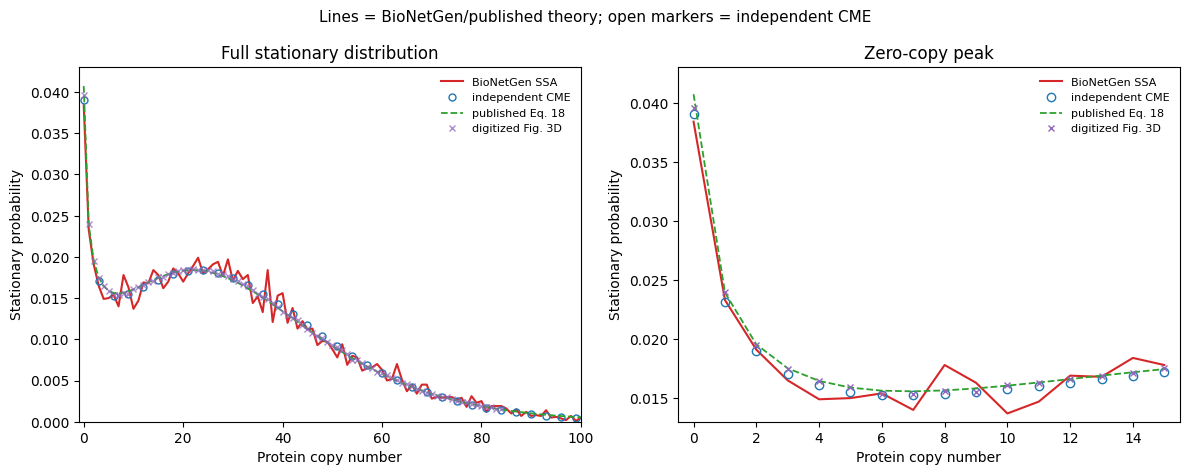

Saved verify_shahrezaei2008.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

counts = np.arange(101)
axes[0].plot(
    counts,
    protein_bng[:101],
    color="#d62728",
    lw=1.5,
    label="BioNetGen SSA",
)
axes[0].plot(
    counts[::3],
    protein_cme[:101:3],
    "o",
    mfc="none",
    mec="#1f77b4",
    ms=5,
    label="independent CME",
)
axes[0].plot(
    n_analytic[:101],
    protein_analytic[:101],
    color="#2ca02c",
    ls="--",
    lw=1.3,
    label="published Eq. 18",
)
axes[0].plot(
    reported_n,
    reported_p,
    "x",
    color="#9467bd",
    ms=4,
    alpha=0.75,
    label="digitized Fig. 3D",
)
axes[0].set(
    xlabel="Protein copy number",
    ylabel="Stationary probability",
    xlim=(-1, 100),
    ylim=(0, 0.043),
    title="Full stationary distribution",
)
axes[0].legend(frameon=False, fontsize=8)

low = np.arange(16)
axes[1].plot(
    low,
    protein_bng[:16],
    color="#d62728",
    lw=1.5,
    label="BioNetGen SSA",
)
axes[1].plot(
    low,
    protein_cme[:16],
    "o",
    mfc="none",
    mec="#1f77b4",
    ms=6,
    label="independent CME",
)
axes[1].plot(
    low,
    protein_analytic[:16],
    color="#2ca02c",
    ls="--",
    lw=1.3,
    label="published Eq. 18",
)
axes[1].plot(
    reported_n[:16],
    reported_p[:16],
    "x",
    color="#9467bd",
    ms=5,
    label="digitized Fig. 3D",
)
axes[1].set(
    xlabel="Protein copy number",
    ylabel="Stationary probability",
    xlim=(-0.5, 15.5),
    ylim=(0.013, 0.043),
    title="Zero-copy peak",
)
axes[1].legend(frameon=False, fontsize=8)

fig.suptitle(
    "Lines = BioNetGen/published theory; open markers = independent CME",
    fontsize=11,
)
fig.tight_layout()
figure_path = MODEL_DIR / "verify_shahrezaei2008.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved {figure_path.name}")

## Result

All assertions pass. The curated seeded BioNetGen outputs are reproducible, the
post-burn-in stationary protein distribution agrees quantitatively with an
independent finite-state CME, and both agree with the reported Fig. 3D
$\gamma=10$ simulation curve within the digitization- and sampling-aware
tolerance. The large-$\gamma$ analytical distribution captures the same
zero-copy peak and broad nonzero mode.